In [31]:
import pandas as pd

# Load data
df = pd.read_csv("E:\\Codding work\\\DataForDataScienceAndAI\\Cars_data.csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["pu", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())
df["car_age"] = 2025 - df["model_year_new"]




<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\narut\AppData\Local\Temp\ipykernel_12944\4042324804.py:4: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\\Codding work\\\DataForDataScienceAndAI\\Cars_data.csv")


         pu  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [32]:
df = df[df["car_age"] <= 30]

In [33]:
print(df['utype'].unique())
owner_type_order = {
    "Individual": 1,
    "Dealer": 2
}
df["utype_encoded"] = df["utype"].map(owner_type_order)
print(df[["utype_encoded", "utype"]].head())

['Individual' 'Dealer']
   utype_encoded       utype
0              1  Individual
1              2      Dealer
2              2      Dealer
3              2      Dealer
4              2      Dealer


In [34]:
print(df['owner_type_new'].unique())
# Ordinal encoding for 'owner_type_new'
owner_type_order = {
    "fifth": 1,
    "fourth": 2,
    "third": 3,
    "second": 4,
    "first": 5,
    "unregistered car": 6,
}
df["owner_type_encoded"] = df["owner_type_new"].map(owner_type_order)
print(df[["owner_type_new", "owner_type_encoded"]].head())

['second' 'first' 'third' 'fourth' 'fifth' 'unregistered car']
  owner_type_new  owner_type_encoded
0         second                   4
1          first                   5
2          first                   5
3          first                   5
4          first                   5


In [35]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [36]:
# Drop rows with missing price
df.dropna(subset=["pu"], inplace=True)

# Fill missing values
#df["mileage_new"].fillna(df["mileage_new"].median())

In [37]:
# Clean 'Top Speed' and 'Acceleration' columns: extract numeric part and convert to float
for col in ["Top Speed", "Acceleration"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"([0-9.]+)")  # Extract numeric part
        .squeeze()
        .astype(float)
    )

# Drop rows with missing values in 'Top Speed' or 'Acceleration'
#df.dropna(subset=["Top Speed", "Acceleration"])
df["Acceleration"] = df["Acceleration"].fillna(df["Acceleration"].median())
df["Top Speed"] = df["Top Speed"].fillna(df["Top Speed"].median())

In [38]:
df = df.dropna(subset=["mileage_new"])
df = df.dropna(subset=["max_power"])
df = df.dropna(subset=["max_torque"])
df = df.dropna(subset=["No of Cylinder"])

In [39]:
#df["max_power"].fillna(df["max_power"].median())
#df["max_torque"].fillna(df["max_torque"].median())

In [40]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

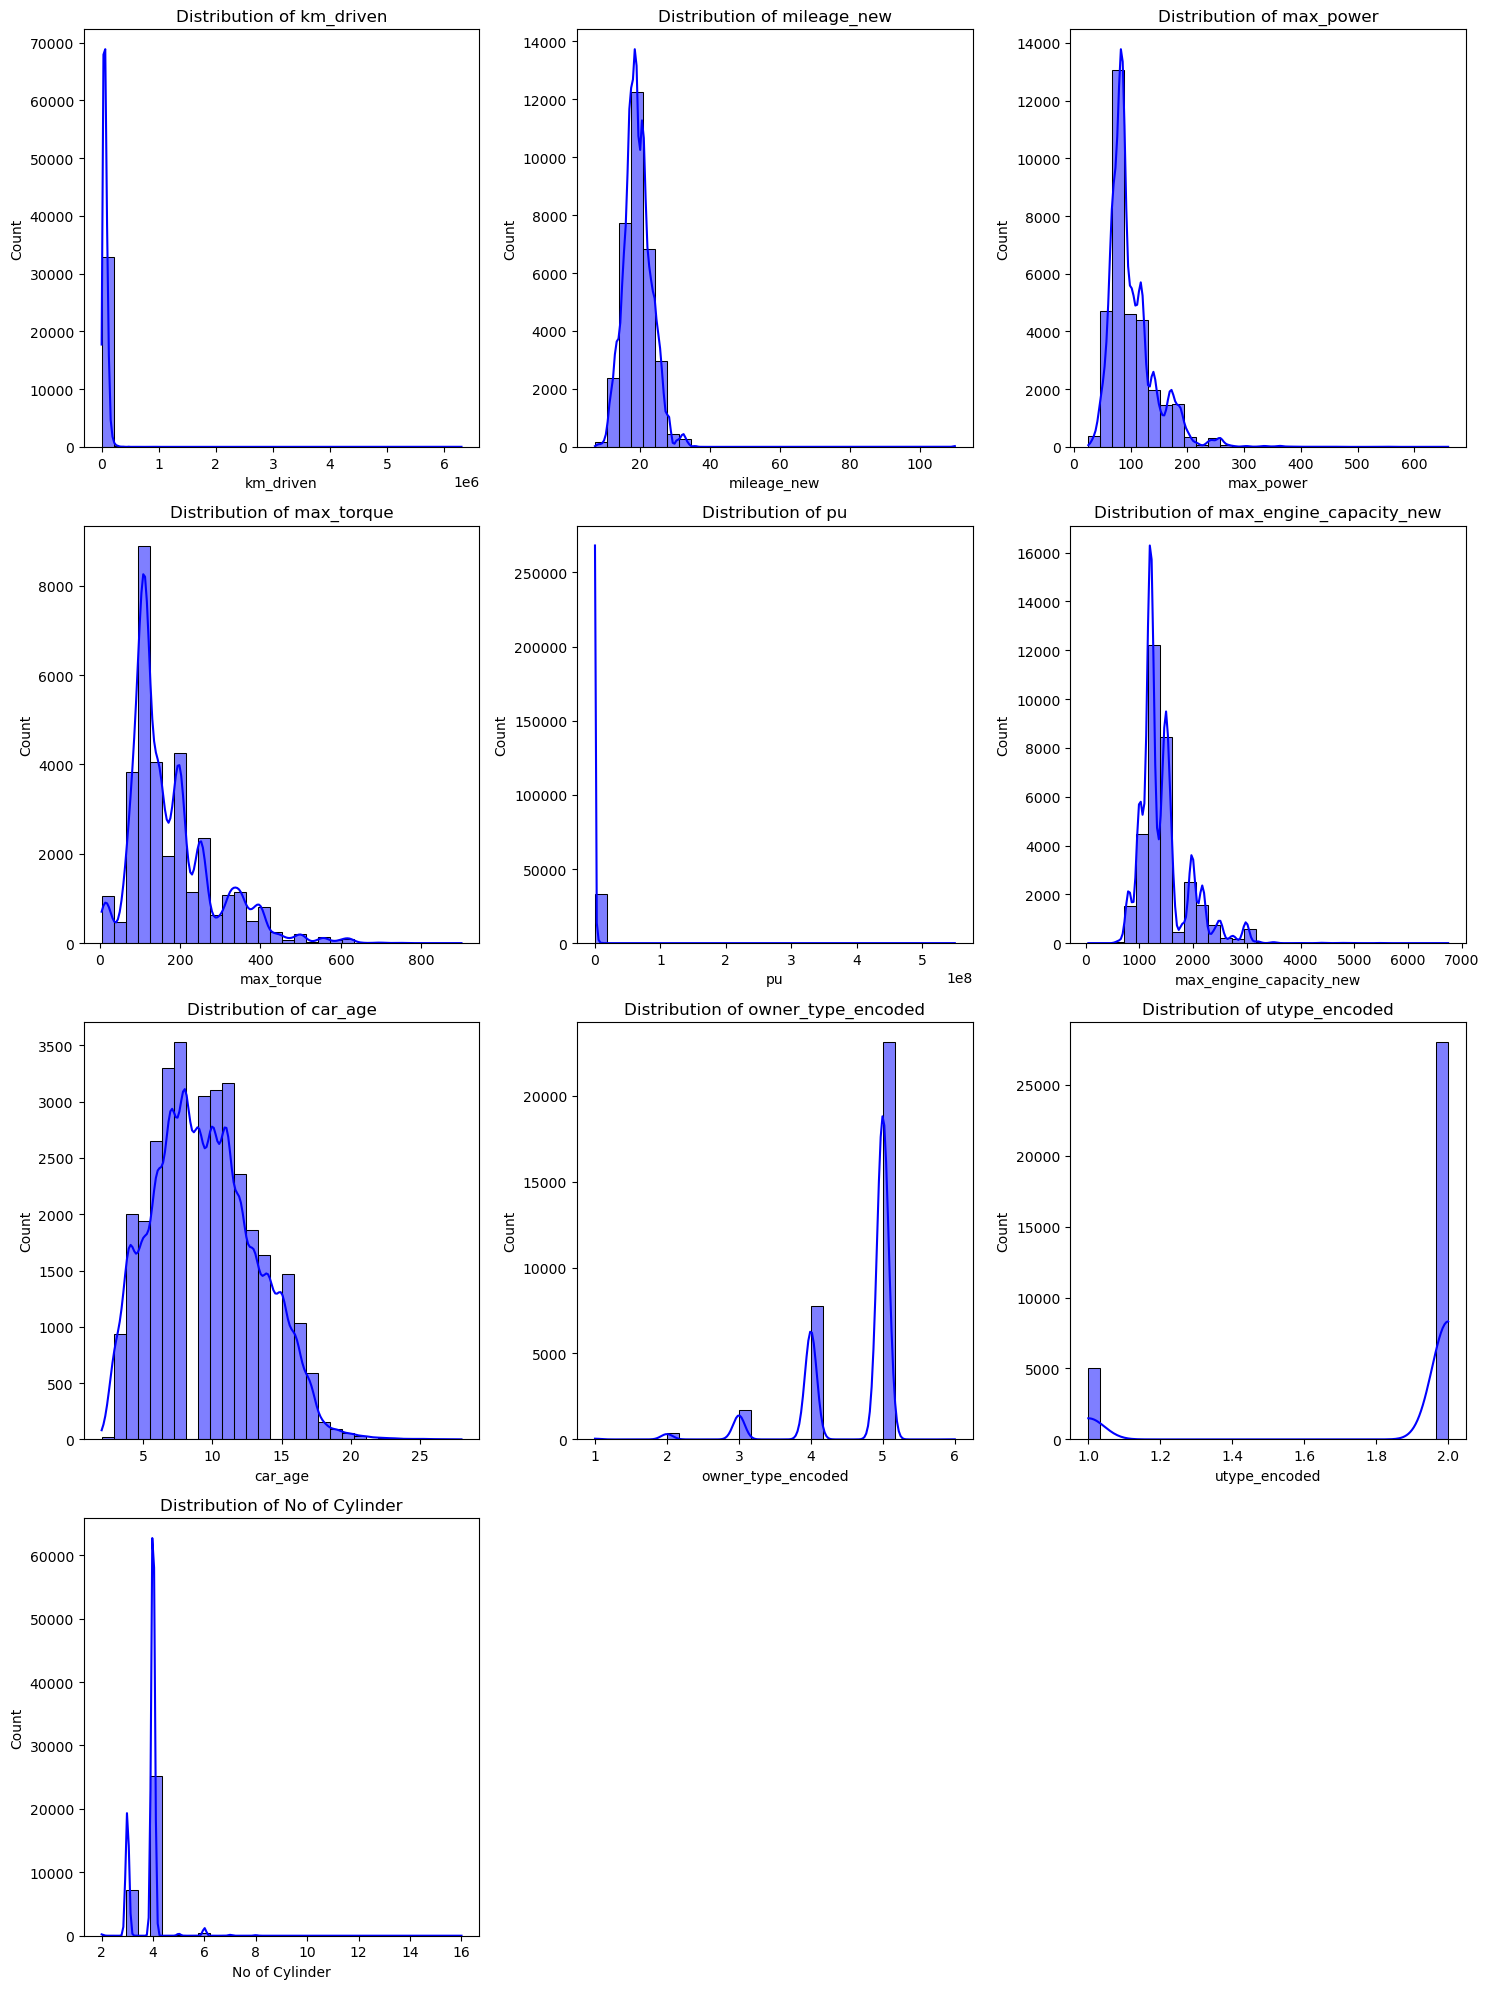

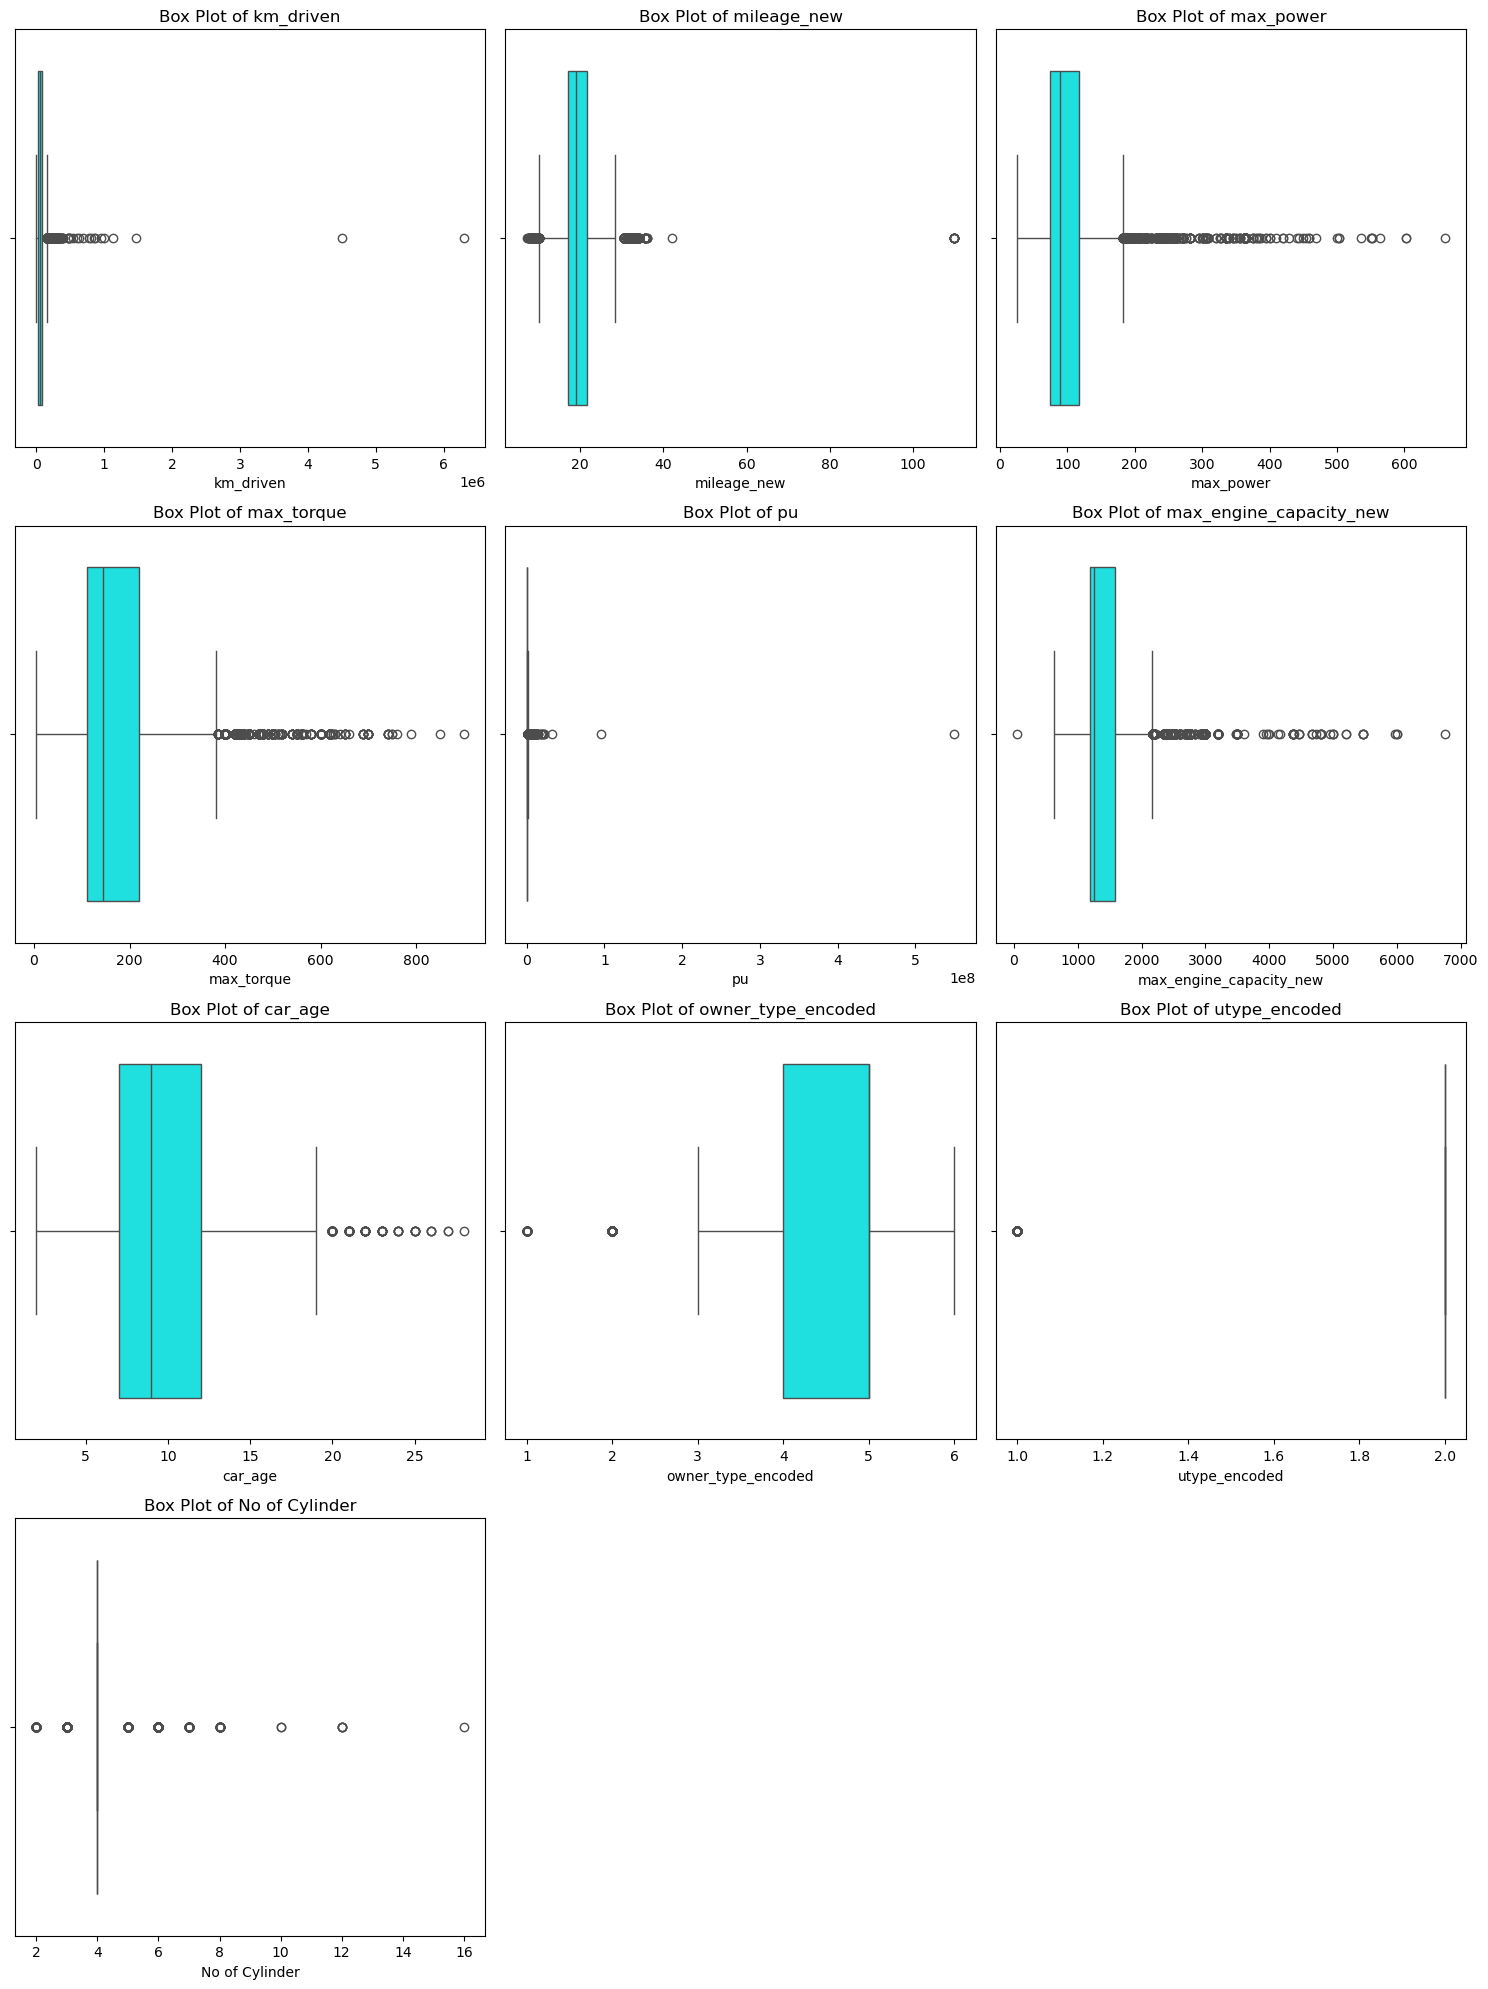

In [41]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "pu",
    "max_engine_capacity_new", "car_age", "owner_type_encoded", "utype_encoded", "No of Cylinder"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [42]:
import numpy as np

# Define columns to check for outliers
log_cols = ["owner_type_encoded",'max_power', 'max_torque', 'max_engine_capacity_new', 
             "km_driven","car_age", "mileage_new", "pu"]

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

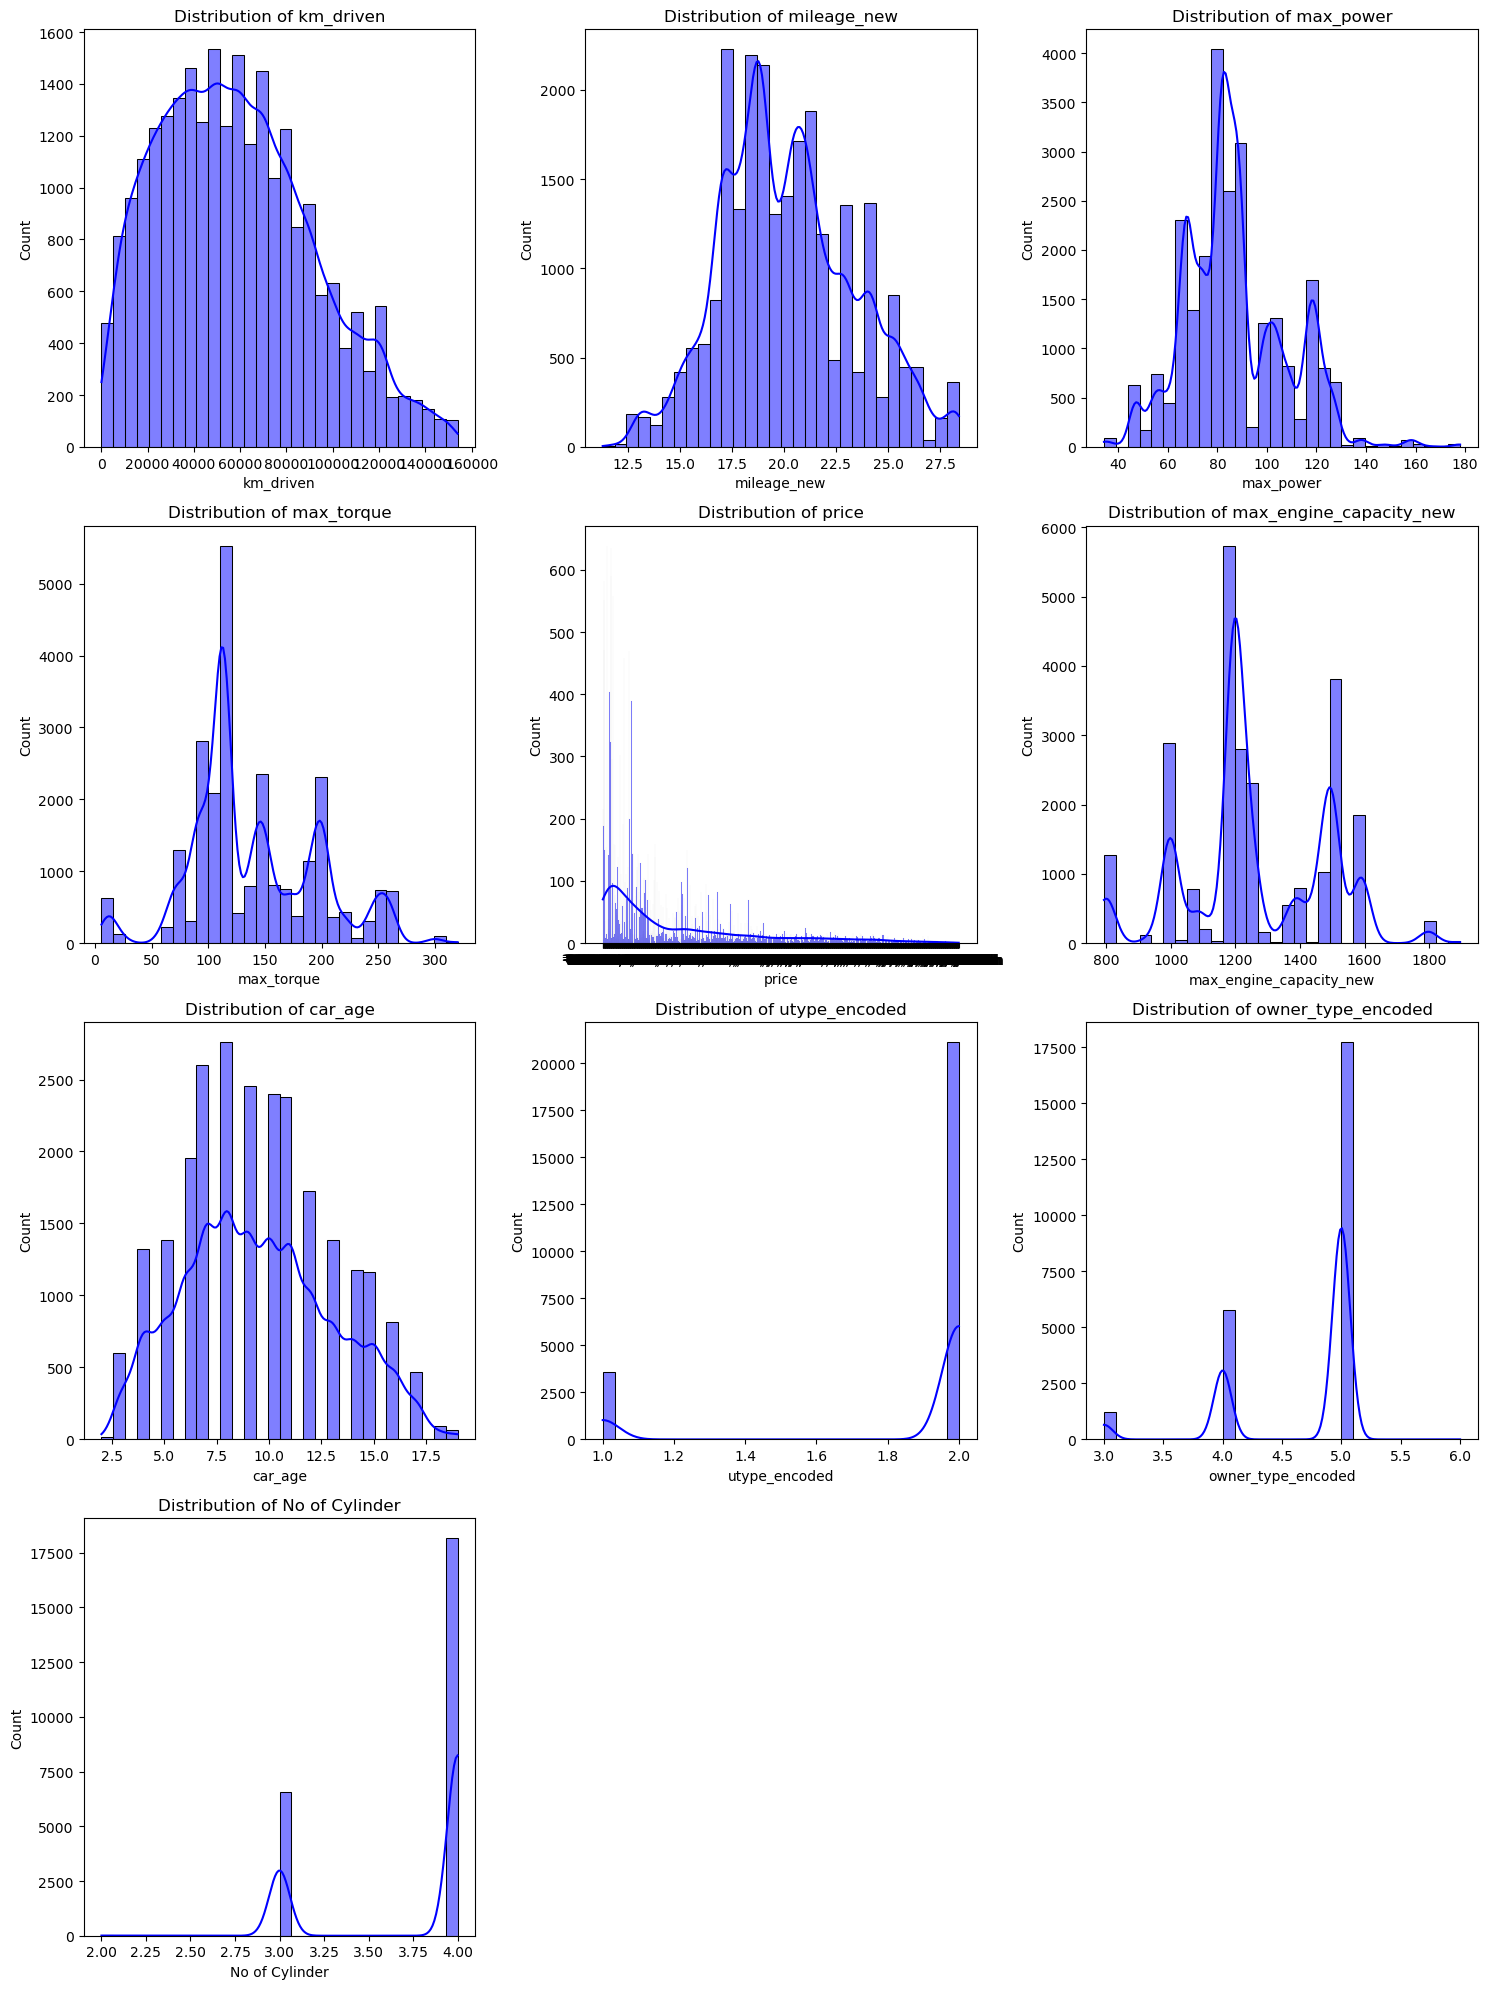

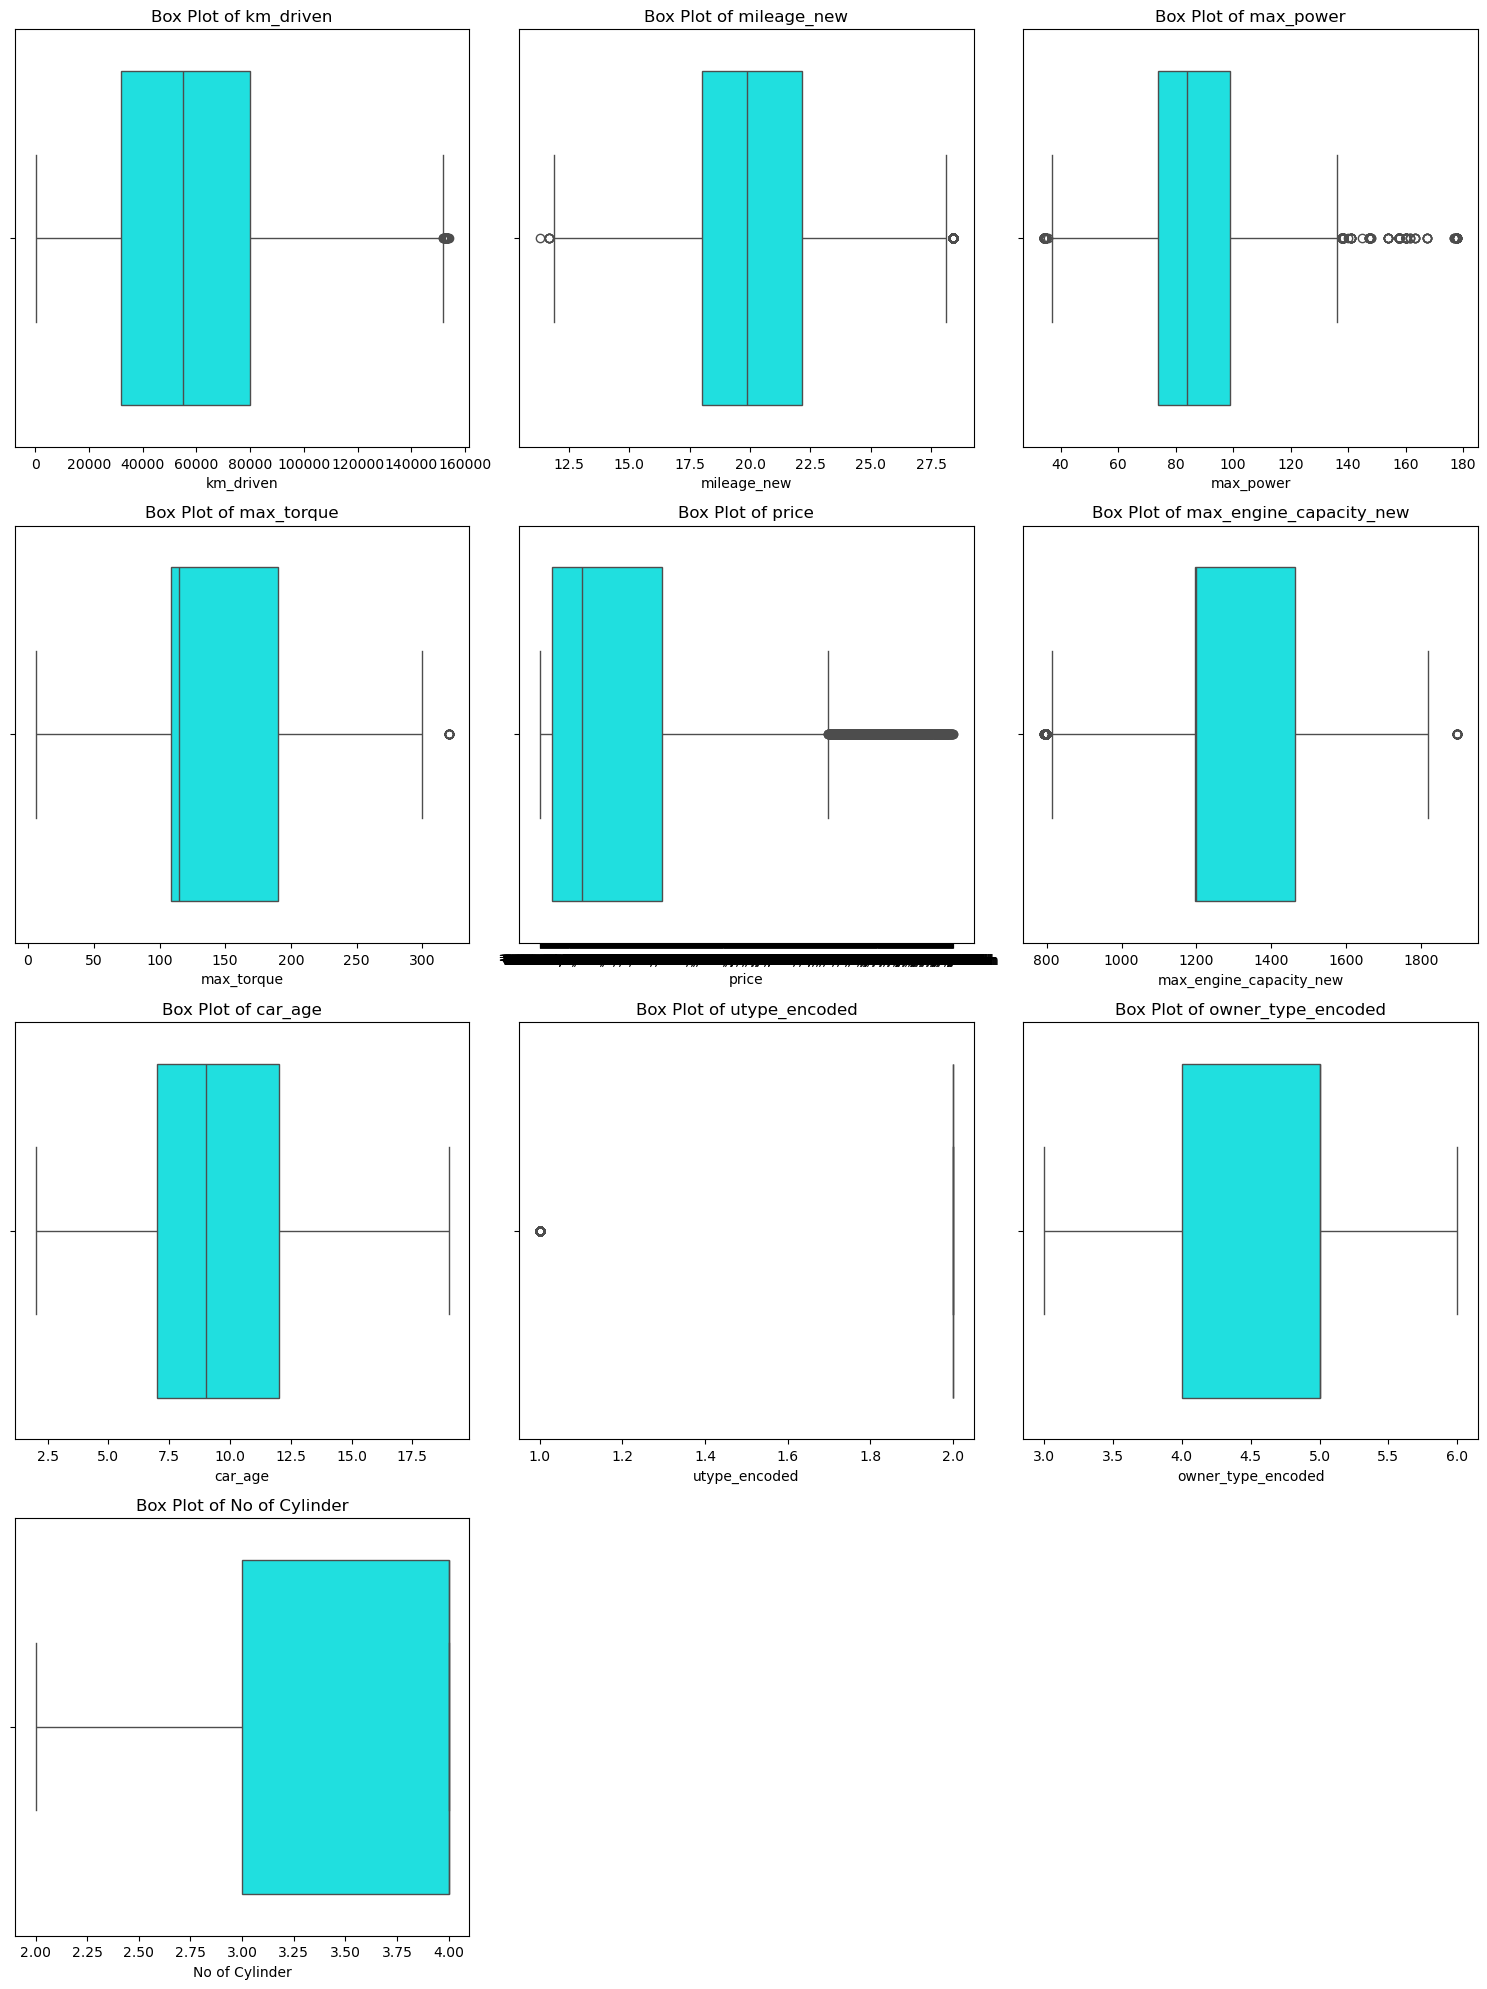

In [43]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "price",
    "max_engine_capacity_new", "car_age", "utype_encoded",
    "owner_type_encoded", "No of Cylinder"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df['max_torque_sqrt'] = np.sqrt(df['max_torque'])
from scipy.stats import boxcox
df['max_torque_boxcox'], _ = boxcox(df['max_torque'] )
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])
df["log_km_driven"] = np.log(df["km_driven"])
df["log_car_age"] = np.log(df["car_age"])
df["log_mileage_new"] = np.log(df["mileage_new"])
df["log_No of Cylinder"] = np.log(df["No of Cylinder"])
df['km_driven_sqrt'] = np.sqrt(df['km_driven'])
from scipy.stats import boxcox
df['km_driven_boxcox'], _ = boxcox(df['km_driven'] )

In [45]:
import numpy as np

features = [
 "km_driven_sqrt", "mileage_new",
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new", "car_age",
   "owner_type_encoded", "utype_encoded", "No of Cylinder", "Top Speed", "Acceleration"   
]
#,"owner_type_encoded", "utype_encoded"
df = df.dropna(subset=["pu"])
df = df.dropna(subset=features)
X = df[features]
#y = df["pu"]
y = np.log(df["pu"])  # Natural logarithm (base e)

In [46]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [47]:
col = "pu"
print("Min:", df[col].min())
print("Max:", df[col].max())
print("Median:", df[col].median())
print("Mean:", df[col].mean())

Min: 44444.0
Max: 1300000.0
Median: 454000.0
Mean: 502826.07641357026


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer
X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)

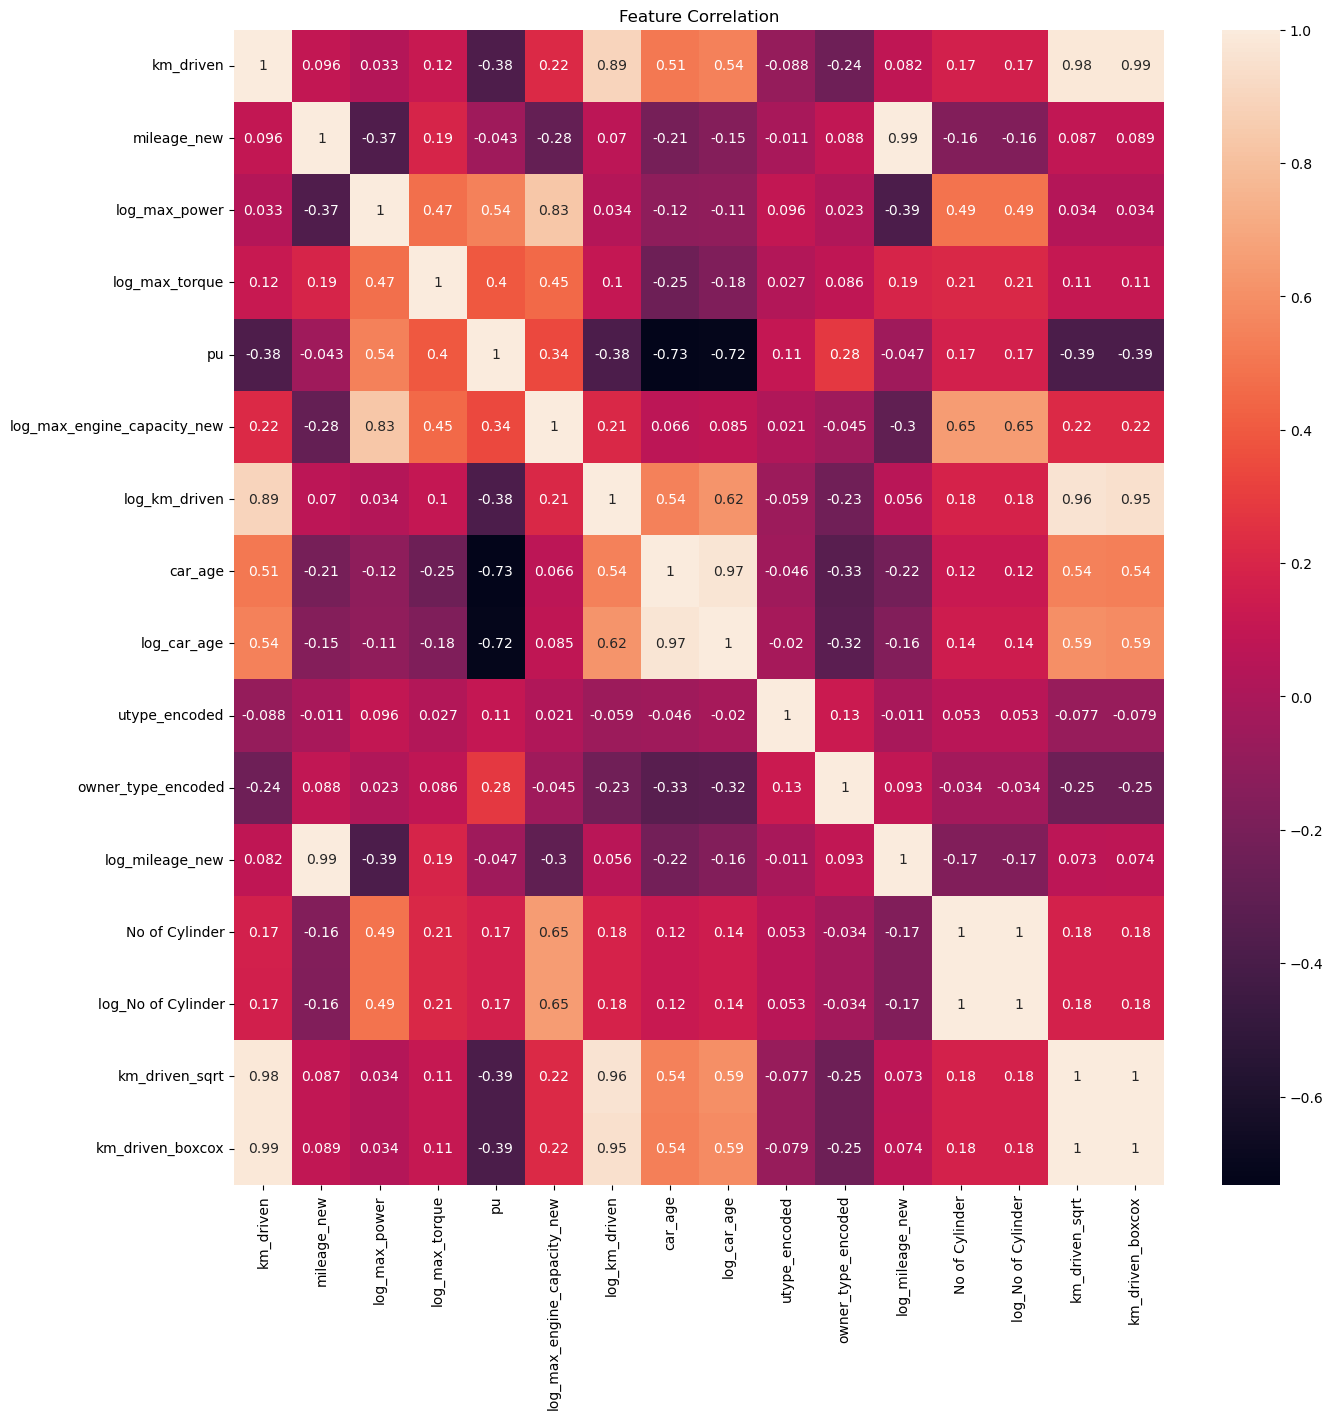

In [49]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "pu",
 "log_max_engine_capacity_new", "log_km_driven", "car_age", "log_car_age", "utype_encoded", "owner_type_encoded",
   "log_mileage_new","No of Cylinder", "log_No of Cylinder", "km_driven_sqrt", "km_driven_boxcox"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

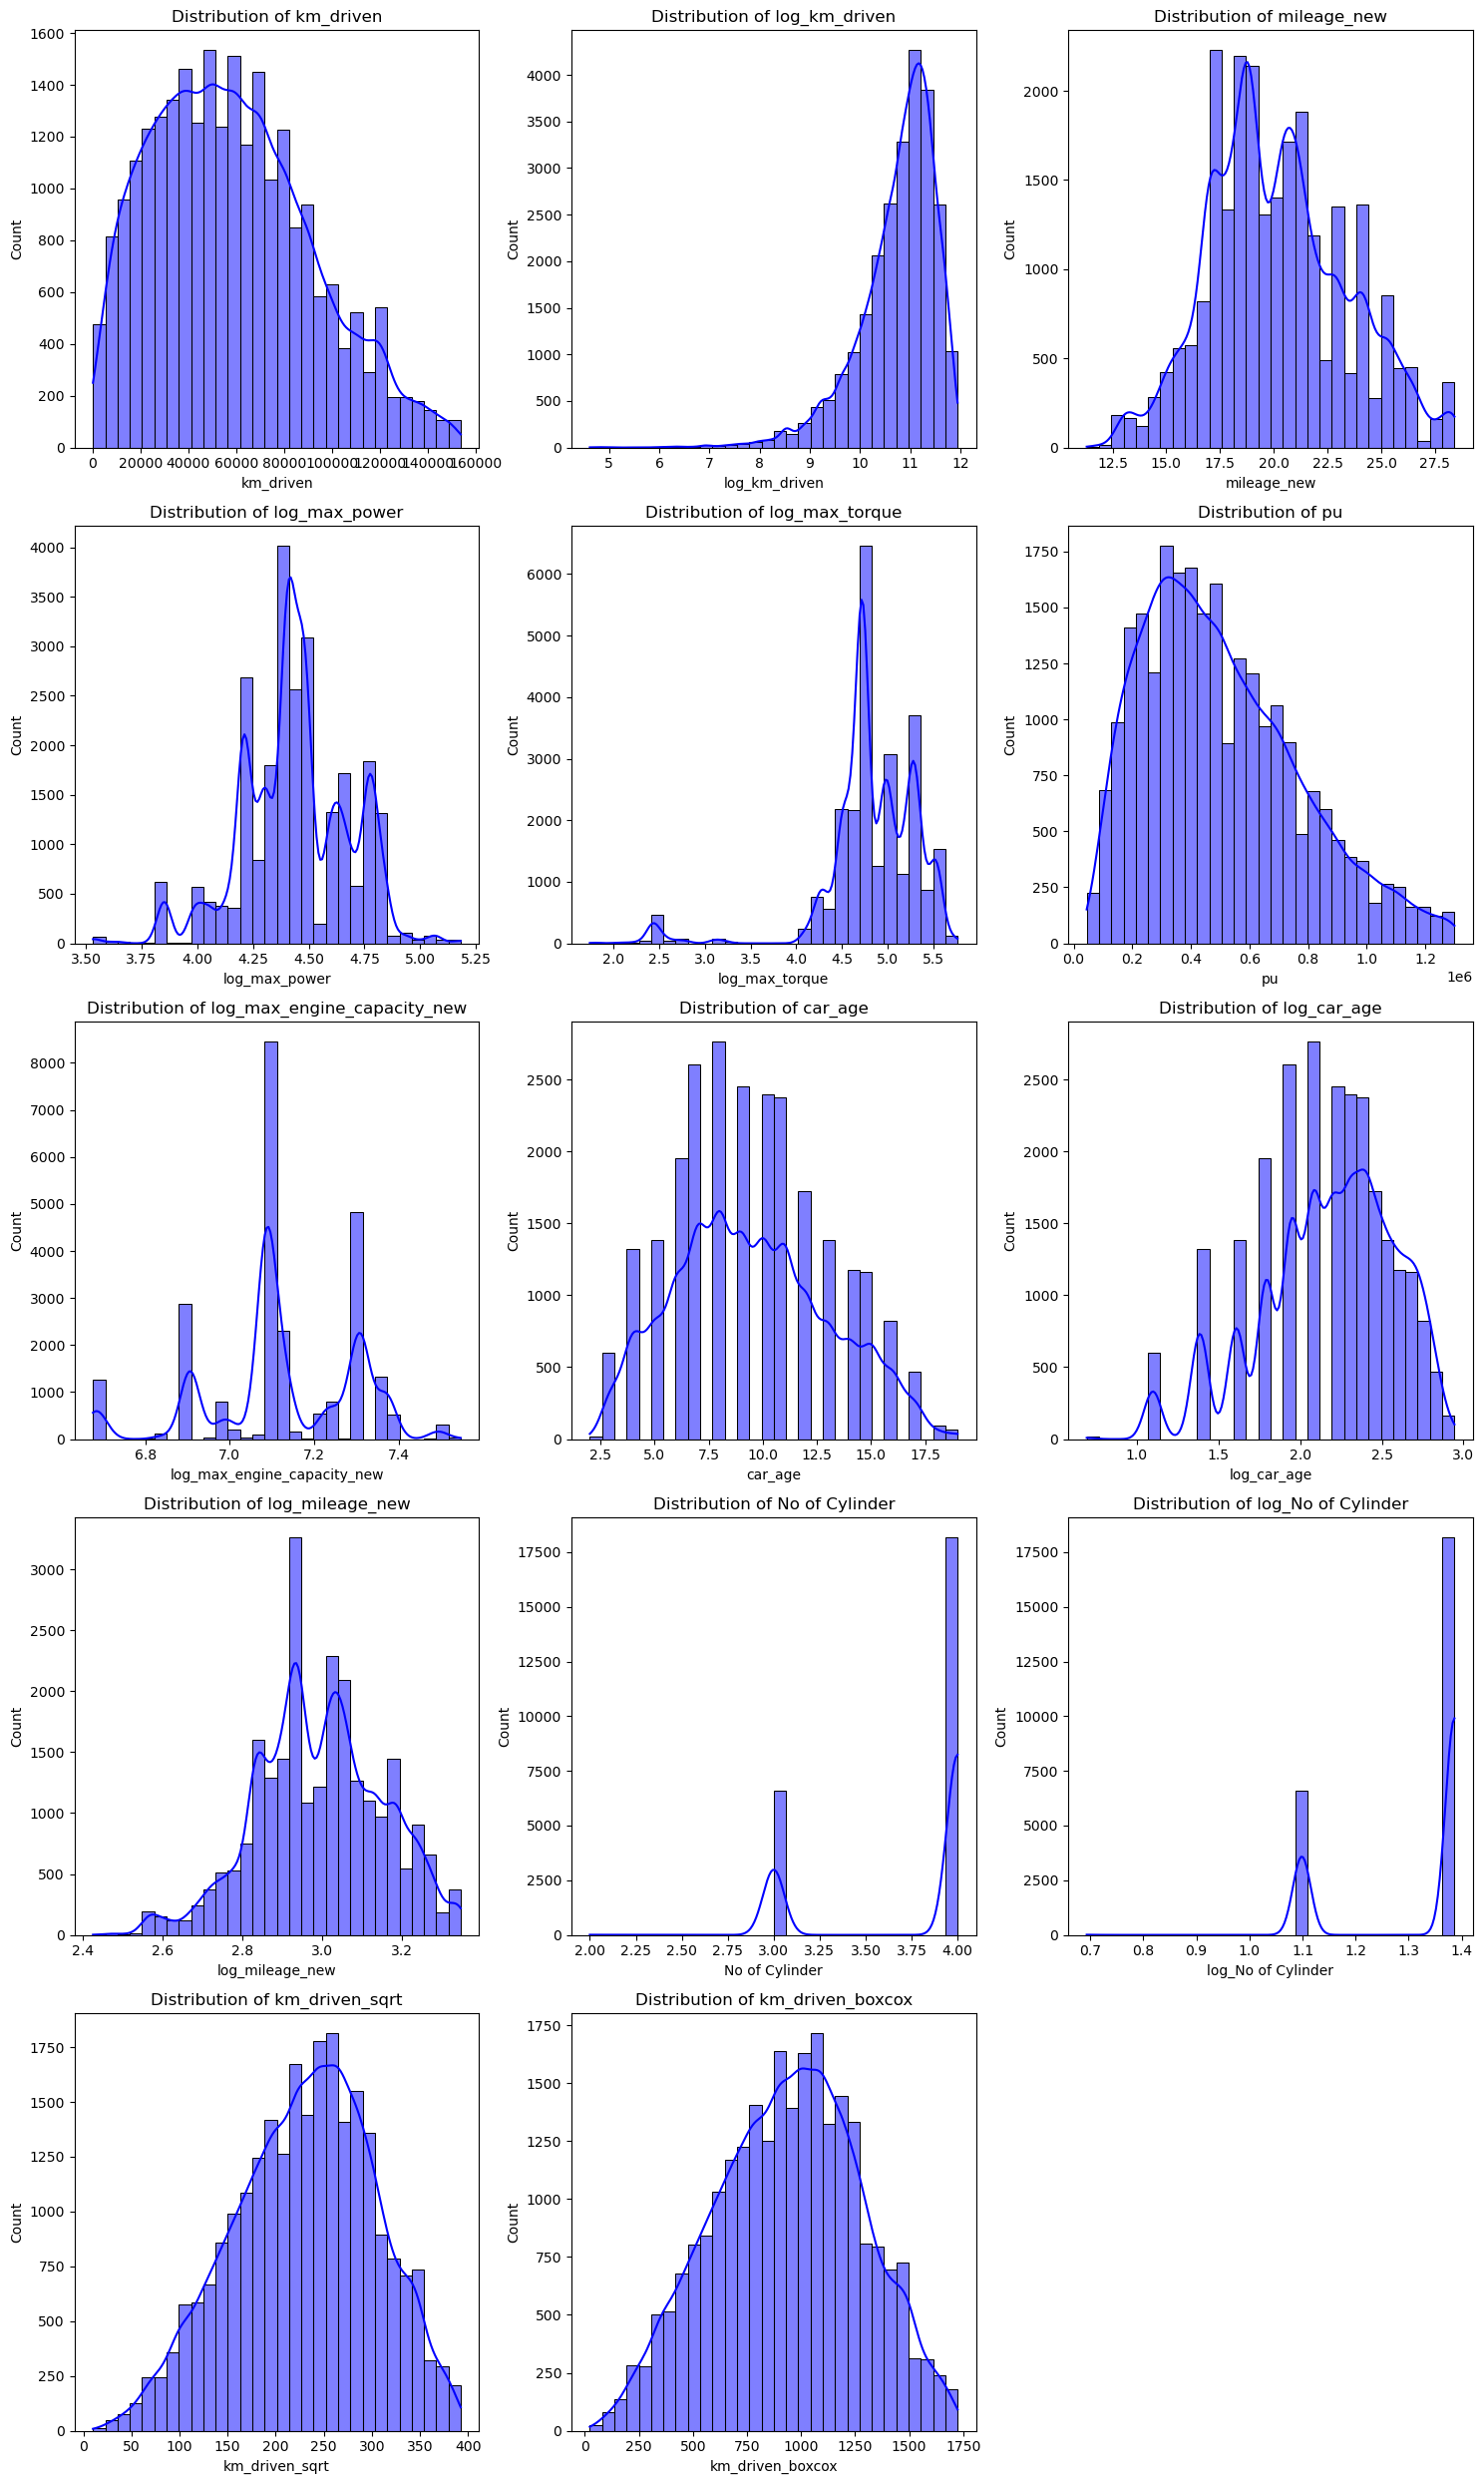

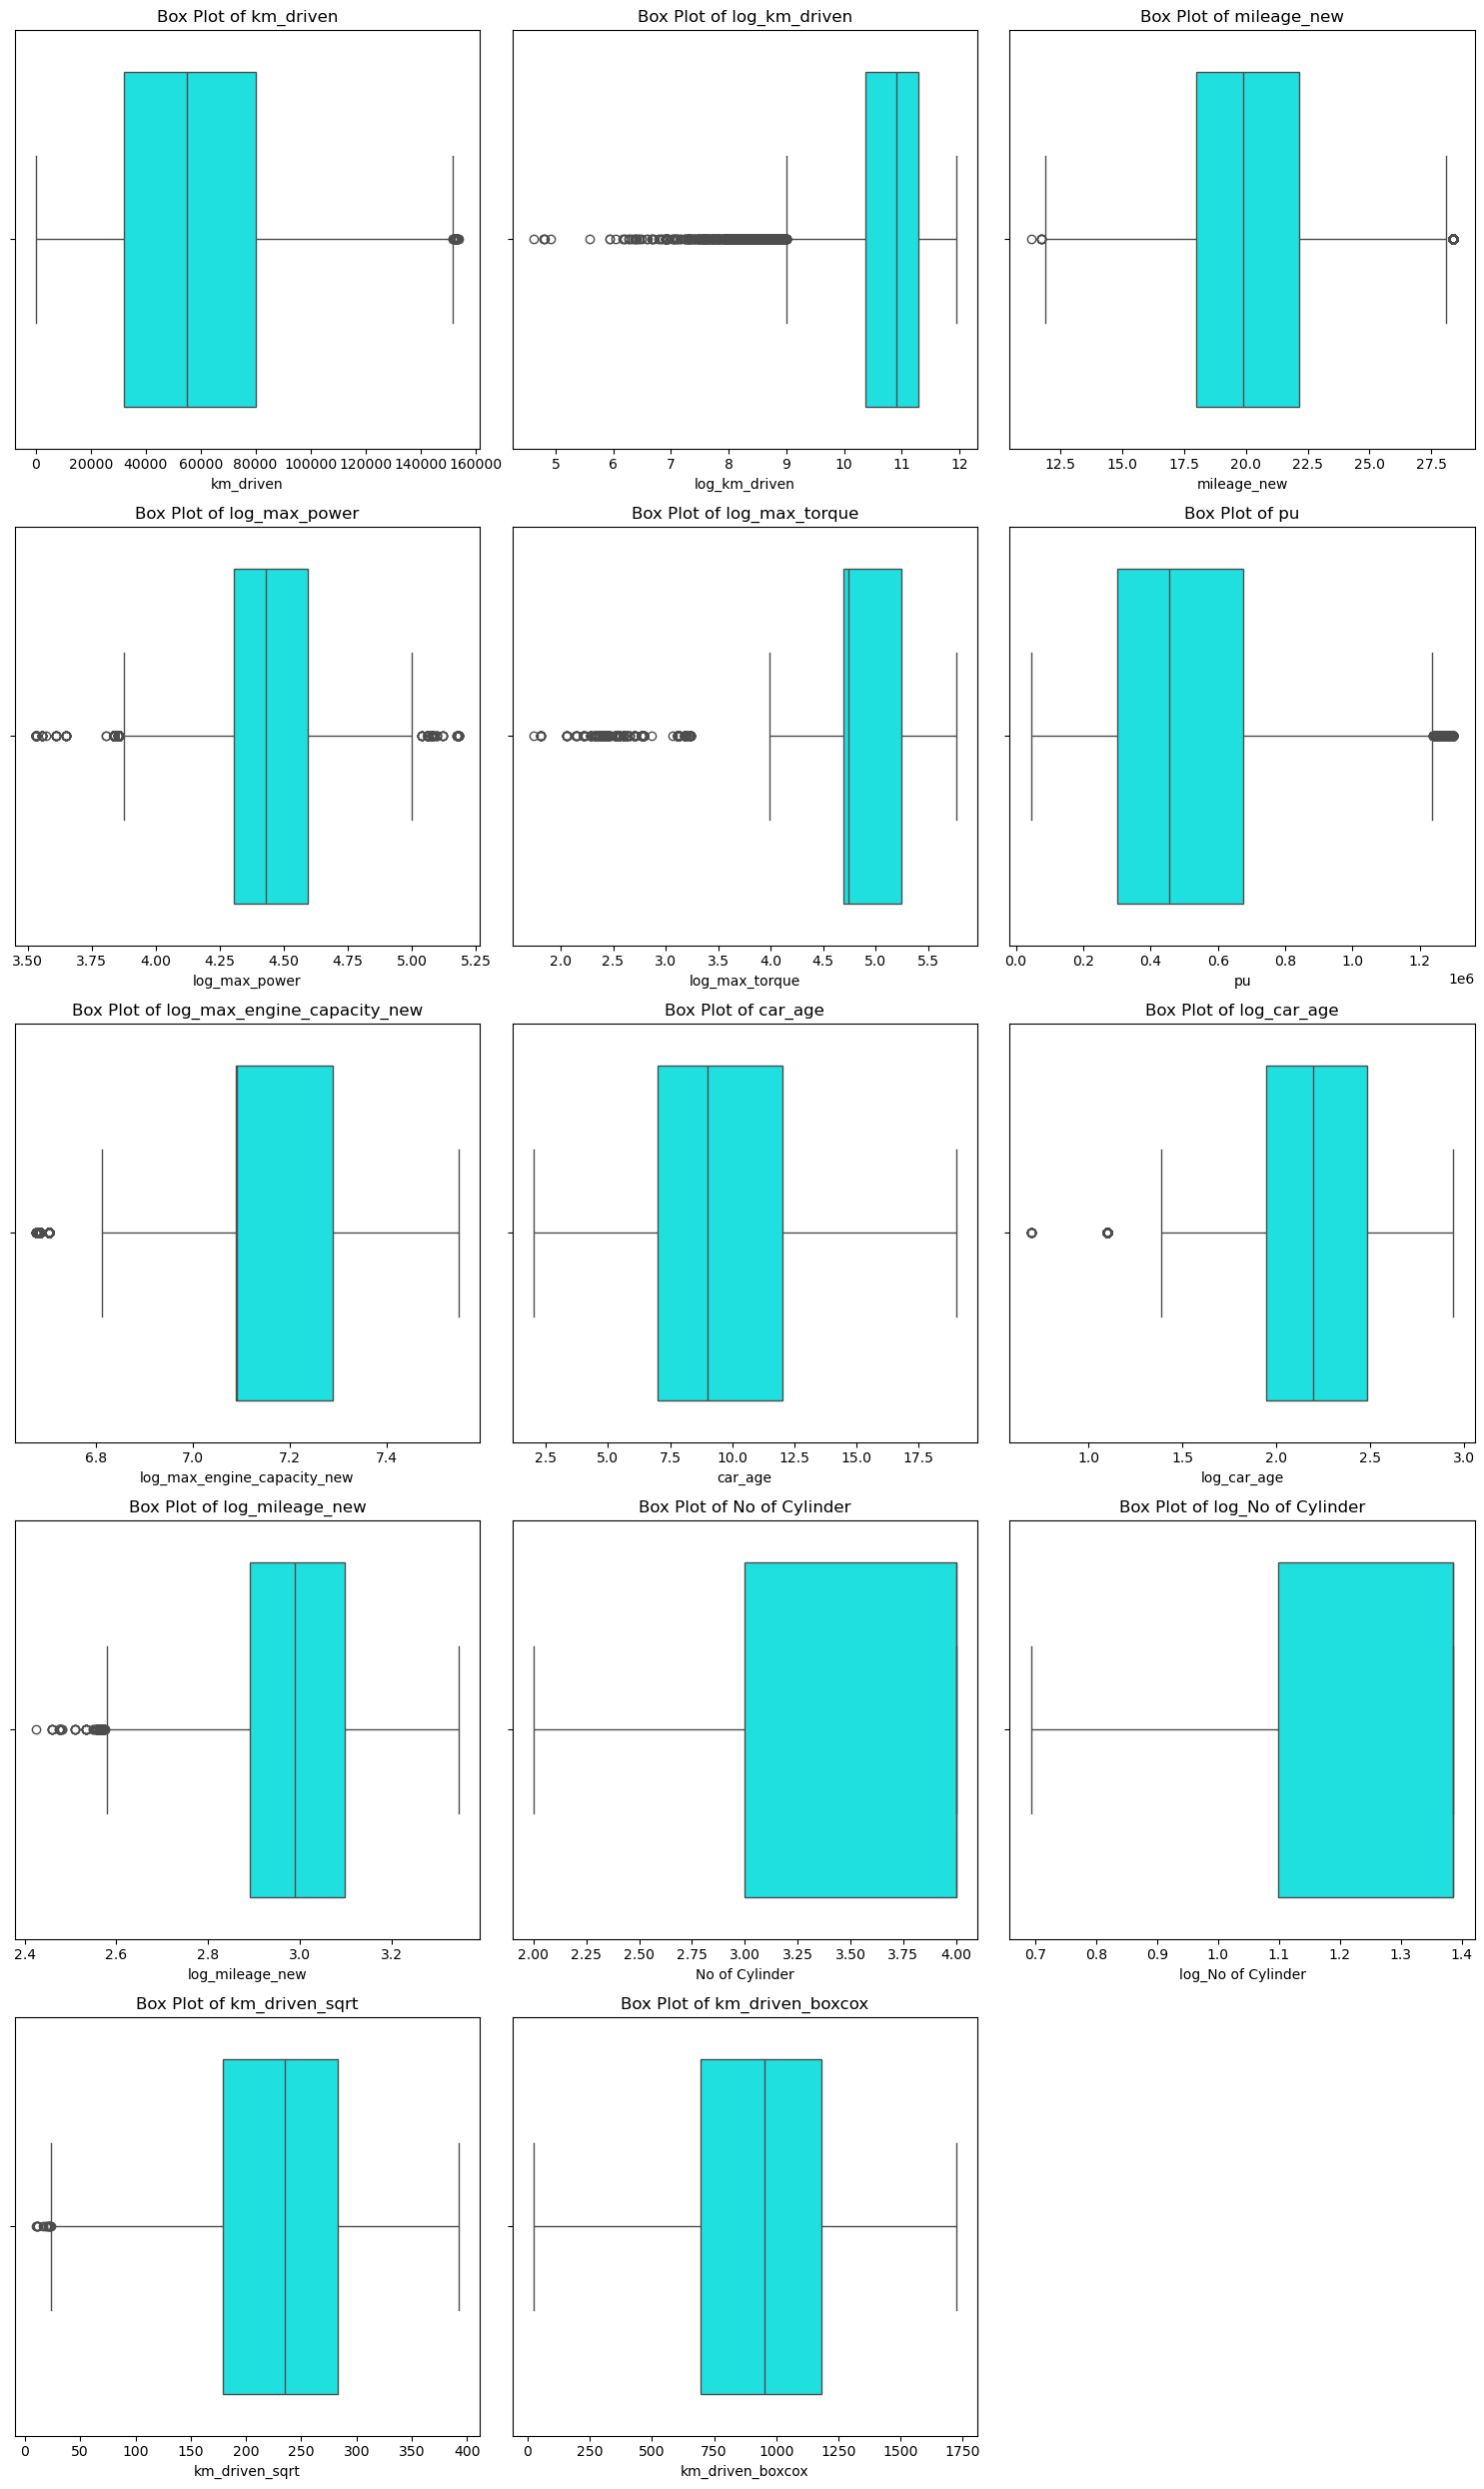

In [50]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "log_km_driven","mileage_new",
    "log_max_power", "log_max_torque", "pu",
    "log_max_engine_capacity_new", "car_age", "log_car_age", "log_mileage_new",
      "No of Cylinder","log_No of Cylinder", "km_driven_sqrt", "km_driven_boxcox"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,289 (923.00 KB)

 Trainable params: 236,289 (923.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.3769 - mae: 2.0363 - val_loss: 0.6177 - val_mae: 0.6631
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.3528 - mae: 1.2451 - val_loss: 0.2676 - val_mae: 0.4404
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.2709 - mae: 0.9016 - val_loss: 0.2421 - val_mae: 0.4168
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6235 - mae: 0.6291 - val_loss: 0.2060 - val_mae: 0.3828
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5084 - mae: 0.5698 - val_loss: 0.1159 - val_mae: 0.2751
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4422 - mae: 0.5315 - val_loss: 0.0885 - val_mae: 0.2190
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4184 - mae: 0.5155 - val_loss: 0.1172 - val_mae: 0.2639
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4097 - mae: 0.5144 - val_loss: 0.5055 - val_mae: 0.6686
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

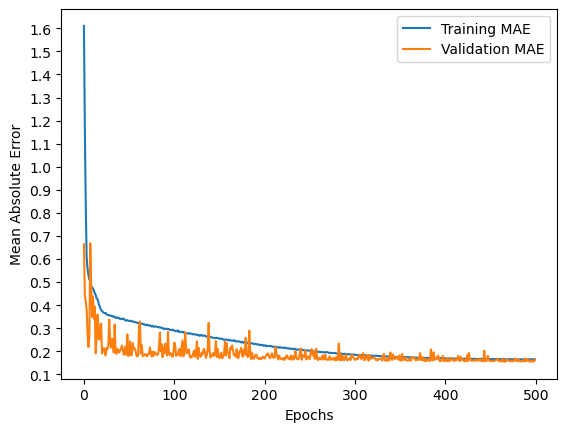

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model11 = Sequential([
    Dense(512, activation="leaky_relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="leaky_relu"),
    Dropout(0.2),
    Dense(256, activation="leaky_relu"),
    Dropout(0.2),
    Dense(128, activation="leaky_relu"),
    Dropout(0.1),
    Dense(1)
])
model11.summary()
model11.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history11 = model11.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history11.history['mae'], label='Training MAE')
plt.plot(history11.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [52]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model11.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE in original price units: 69866.67400994863


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 36.0777 - mae: 4.3959 - val_loss: 1.0384 - val_mae: 0.9283
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.4152 - mae: 1.8597 - val_loss: 0.1650 - val_mae: 0.3071
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.3575 - mae: 1.6605 - val_loss: 0.1377 - val_mae: 0.3064
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.5578 - mae: 1.5062 - val_loss: 0.1275 - val_mae: 0.2976
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7224 - mae: 1.3102 - val_loss: 0.2773 - val_mae: 0.4741
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3551 - mae: 1.2119 - val_loss: 0.0968 - val_mae: 0.2542
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0834 - mae: 1.1412 - val_loss: 0.0844 - val_mae: 0.2327
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9351 - mae: 1.0961 - val_loss: 0.0696 - val_mae: 0.2025
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms

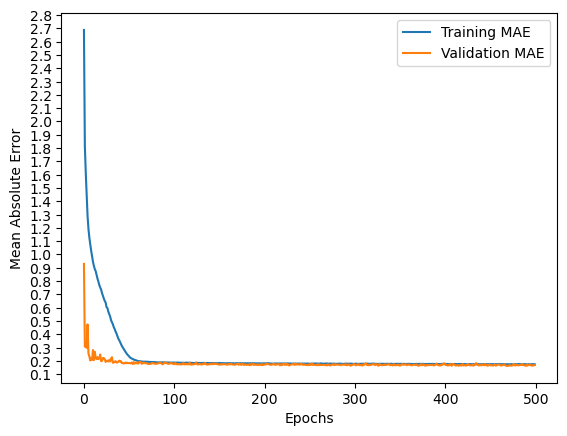

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model1.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [54]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model1.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step
MAE in original price units: 72023.40806784191


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,289 (923.00 KB)

 Trainable params: 236,289 (923.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9212 - mae: 2.0497 - val_loss: 3.2978 - val_mae: 1.7772
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.6519 - mae: 1.3312 - val_loss: 0.1348 - val_mae: 0.2757
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.8271 - mae: 1.0961 - val_loss: 0.3593 - val_mae: 0.5375
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8135 - mae: 0.7199 - val_loss: 0.0906 - val_mae: 0.2445
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5908 - mae: 0.6139 - val_loss: 0.1093 - val_mae: 0.2504
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5472 - mae: 0.5892 - val_loss: 0.0719 - val_mae: 0.2066
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5420 - mae: 0.5838 - val_loss: 0.0704 - val_mae: 0.2066
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5171 - mae: 0.5740 - val_loss: 0.2133 - val_mae: 0.4051
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

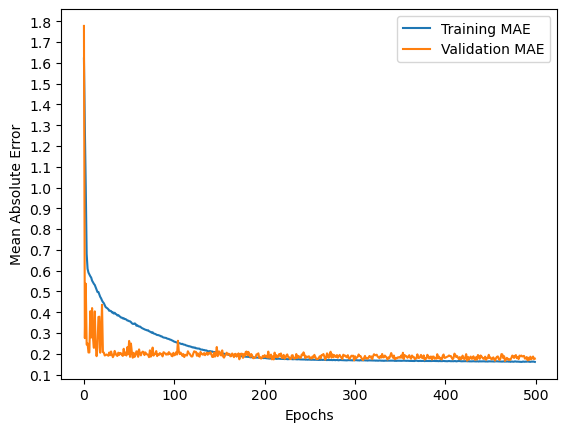

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model4.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks4444444444444444444

plt.show()


In [56]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model4.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#m
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE in original price units: 80705.37391852408


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,689 (698.00 KB)

 Trainable params: 178,689 (698.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.9025 - mae: 2.1585 - val_loss: 0.3888 - val_mae: 0.4863
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.8806 - mae: 1.3660 - val_loss: 0.7975 - val_mae: 0.8291
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.1858 - mae: 1.1937 - val_loss: 0.7862 - val_mae: 0.8154
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.5792 - mae: 1.0100 - val_loss: 0.5656 - val_mae: 0.7024
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2303 - mae: 0.8830 - val_loss: 0.1168 - val_mae: 0.2829
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0114 - mae: 0.8004 - val_loss: 0.0985 - val_mae: 0.2359
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8765 - mae: 0.7477 - val_loss: 0.2037 - val_mae: 0.3823
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8190 - mae: 0.7234 - val_loss: 0.1123 - val_mae: 0.2753
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

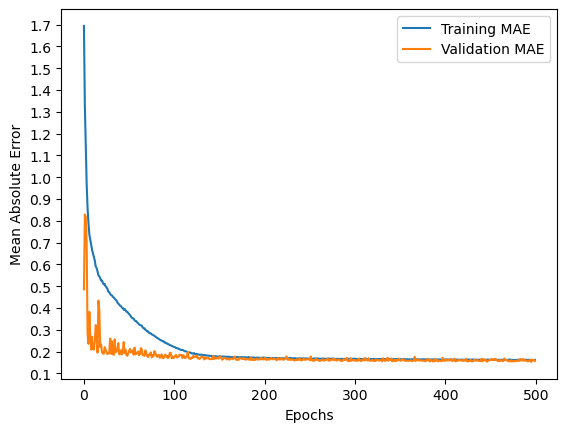

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(512, activation="leaky_relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="leaky_relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1, activation="linear")
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model5.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [58]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model5.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step
MAE in original price units: 65943.07158368778


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,153 (1.65 MB)

 Trainable params: 433,153 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 8.8530 - mae: 2.0708 - val_loss: 1.2011 - val_mae: 1.0258
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.7751 - mae: 1.3533 - val_loss: 0.3803 - val_mae: 0.5472
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.8811 - mae: 1.1063 - val_loss: 0.3309 - val_mae: 0.5079
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.1000 - mae: 0.8409 - val_loss: 0.3551 - val_mae: 0.5383
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8392 - mae: 0.7309 - val_loss: 0.3461 - val_mae: 0.5311
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6621 - mae: 0.6489 - val_loss: 0.0791 - val_mae: 0.2203
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5465 - mae: 0.5895 - val_loss: 0.1231 - val_mae: 0.2964
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4860 - mae: 0.5540 - val_loss: 0.2061 - val_mae: 0.3987
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

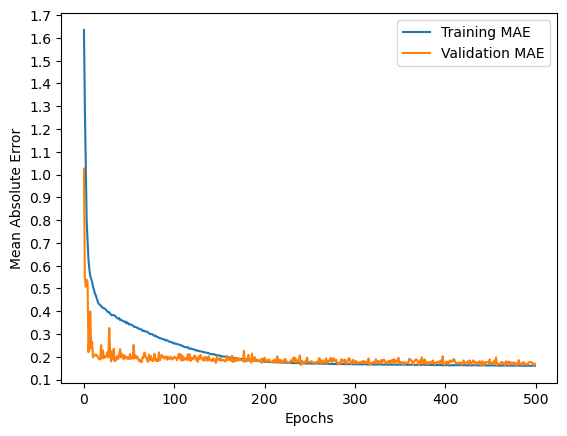

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model9 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model9.summary()
model9.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model9.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [60]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model9.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#m
mae_real = mean_absolute_error(y_true, y_pred)
print("MAE in original price units:", mae_real)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE in original price units: 72987.67372123952
